# Results: RF vs. TabPFN (zero-shot and fine-tuned) Across Information Layers

Combines the RF (subsampled + full), TabPFN zero-shot and TabPFN fine-tuned summary tables into one comparison, runs paired DeLong's tests for AUC-ROC on every model pair within each layer and every layer pair within each model (Bonferroni-corrected per family, with ΔAUC effect sizes and confidence intervals), and produces the comparison figures used in the results chapters.

In [97]:
from pathlib import Path
from itertools import combinations
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

scripts_dir = (Path.cwd() / ".." / "scripts").resolve()
sys.path.append(str(scripts_dir))

from config import final_data_path

final_data_path = Path(final_data_path)
results_dir = final_data_path / "modeling_results"
rf_dir = results_dir / "rf"
tabpfn_dir = results_dir / "fm"
rf_full_dir = results_dir / "rf_full"
tabpfn_tuned_dir = results_dir / "fm_tuned"
fm_tuned_proba_template = "{key}_finetuned_y_proba.npy"

layer_files = [
    "layer_a_bts",
    "layer_b_bts_meteostat",
    "layer_c_bts_gdelt",
    "layer_d_bts_meteostat_gdelt",
]

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.grid.axis": "y",
})

metrics = ["f1", "recall", "precision", "auc_roc", "auc_pr", "mcc"]
metric_labels = {
    "f1": "F1", "recall": "Recall", "precision": "Precision",
    "auc_roc": "AUC-ROC", "auc_pr": "AUC-PR", "mcc": "MCC",
}
model_colors = {"RF": "#4C72B0", "TabPFN": "#DD8452", "TabPFN (FT)": "#C44E52", "RF (Full)": "#55A868"}
layer_order = ["A: BTS", "B: BTS+Weather", "C: BTS+GDELT", "D: BTS+Weather+GDELT"]


## 1. Load result summaries

In [98]:
rf_df = pd.read_csv(rf_dir / "rf_subsampled_summary.csv", index_col="layer")
fm_df = pd.read_csv(tabpfn_dir / "fm_subsampled_summary.csv", index_col="layer")
fm_tuned_df = pd.read_csv(tabpfn_tuned_dir / "fm_finetuned_summary.csv", index_col="layer")
rf_full_df = pd.read_csv(rf_full_dir / "rf_full_summary.csv", index_col="layer")

fm_tuned_df = fm_tuned_df.rename(columns={"roc_auc": "auc_roc", "pr_auc": "auc_pr"})
missing = set(metrics) - set(fm_tuned_df.columns)
assert not missing, f"fm_tuned_summary.csv is missing metric columns: {missing}"

rf_df["model"] = "RF"
fm_df["model"] = "TabPFN"
fm_tuned_df["model"] = "TabPFN (FT)"
rf_full_df["model"] = "RF (Full)"

print(f"RF: {rf_df.shape} | TabPFN: {fm_df.shape} | TabPFN (FT): {fm_tuned_df.shape} | RF (Full): {rf_full_df.shape}")


RF: (4, 10) | TabPFN: (4, 11) | TabPFN (FT): (4, 18) | RF (Full): (4, 10)


In [99]:
def canonicalize_layer(name: str) -> str:
    name = name.lower()
    has_weather = "meteostat" in name or "weather" in name
    has_gdelt = "gdelt" in name
    if has_weather and has_gdelt:
        return "D: BTS+Weather+GDELT"
    elif has_weather:
        return "B: BTS+Weather"
    elif has_gdelt:
        return "C: BTS+GDELT"
    else:
        return "A: BTS"


for df in (rf_df, fm_df, fm_tuned_df, rf_full_df):
    df["layer_label"] = df.index.map(canonicalize_layer)

sources = {"RF": rf_df, "TabPFN": fm_df, "TabPFN (FT)": fm_tuned_df, "RF (Full)": rf_full_df}
for label, df in sources.items():
    assert set(df["layer_label"]) == set(layer_order), (
        f"{label} doesn't cover the 4 layers (has {sorted(df['layer_label'])}) -- check raw layer names above"
    )
print("OK -- all four sources cover:", layer_order)


OK -- all four sources cover: ['A: BTS', 'B: BTS+Weather', 'C: BTS+GDELT', 'D: BTS+Weather+GDELT']


## 2. Combine into one table

In [100]:
combined_df = pd.concat([
    rf_df.reset_index(drop=True),
    fm_df.reset_index(drop=True),
    fm_tuned_df.reset_index(drop=True),
    rf_full_df.reset_index(drop=True),
])
combined_df.to_csv(results_dir / "rf_vs_fm_combined.csv", index=False)

comparison_table = combined_df.pivot(index="layer_label", columns="model", values=metrics)
comparison_table = comparison_table.reindex(layer_order)
comparison_table = comparison_table.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)
comparison_table.to_csv(results_dir / "rf_vs_fm_comparison_table.csv")

comparison_table


model                       RF                                          \
                        auc_pr   auc_roc        f1       mcc precision   
layer_label                                                              
A: BTS                0.356510  0.673140  0.421933  0.207643  0.313103   
B: BTS+Weather        0.369668  0.685567  0.430714  0.225541  0.331093   
C: BTS+GDELT          0.356502  0.677162  0.423714  0.214926  0.326103   
D: BTS+Weather+GDELT  0.367474  0.686012  0.429653  0.226426  0.336769   

model                          RF (Full)                                ...  \
                        recall    auc_pr   auc_roc        f1       mcc  ...   
layer_label                                                             ...   
A: BTS                0.646725  0.361823  0.677831  0.425136  0.214211  ...   
B: BTS+Weather        0.616085  0.373244  0.688841  0.431579  0.229775  ...   
C: BTS+GDELT          0.604726  0.359337  0.679972  0.424262  0.218203  ...   
D: BTS+Weather+GDELT  0.593285  0.370293  0.688929  0.431343  0.230498  ...   

model                   TabPFN                               TabPFN (FT)  \
                            f1       mcc precision    recall      auc_pr   
layer_label                                                                
A: BTS                0.421864  0.206350  0.309389  0.662827    0.357110   
B: BTS+Weather        0.428440  0.216020  0.305810  0.715261    0.366396   
C: BTS+GDELT          0.423720  0.208678  0.307795  0.679728    0.349539   
D: BTS+Weather+GDELT  0.429536  0.219194  0.315336  0.673417    0.360264   

model                                                                   
                       auc_roc        f1       mcc precision    recall  
layer_label                                                             
A: BTS                0.673820  0.423377  0.209519  0.312681  0.655406  
B: BTS+Weather        0.684994  0.431440  0.222382  0.316857  0.675837  
C: BTS+GDELT          0.671538  0.419958  0.207512  0.319439  0.612787  
D: BTS+Weather+GDELT  0.682408  0.429590  0.221674  0.324072  0.636997  

[4 rows x 24 columns]

## 3a. Figure — model comparison across layers (bar chart)

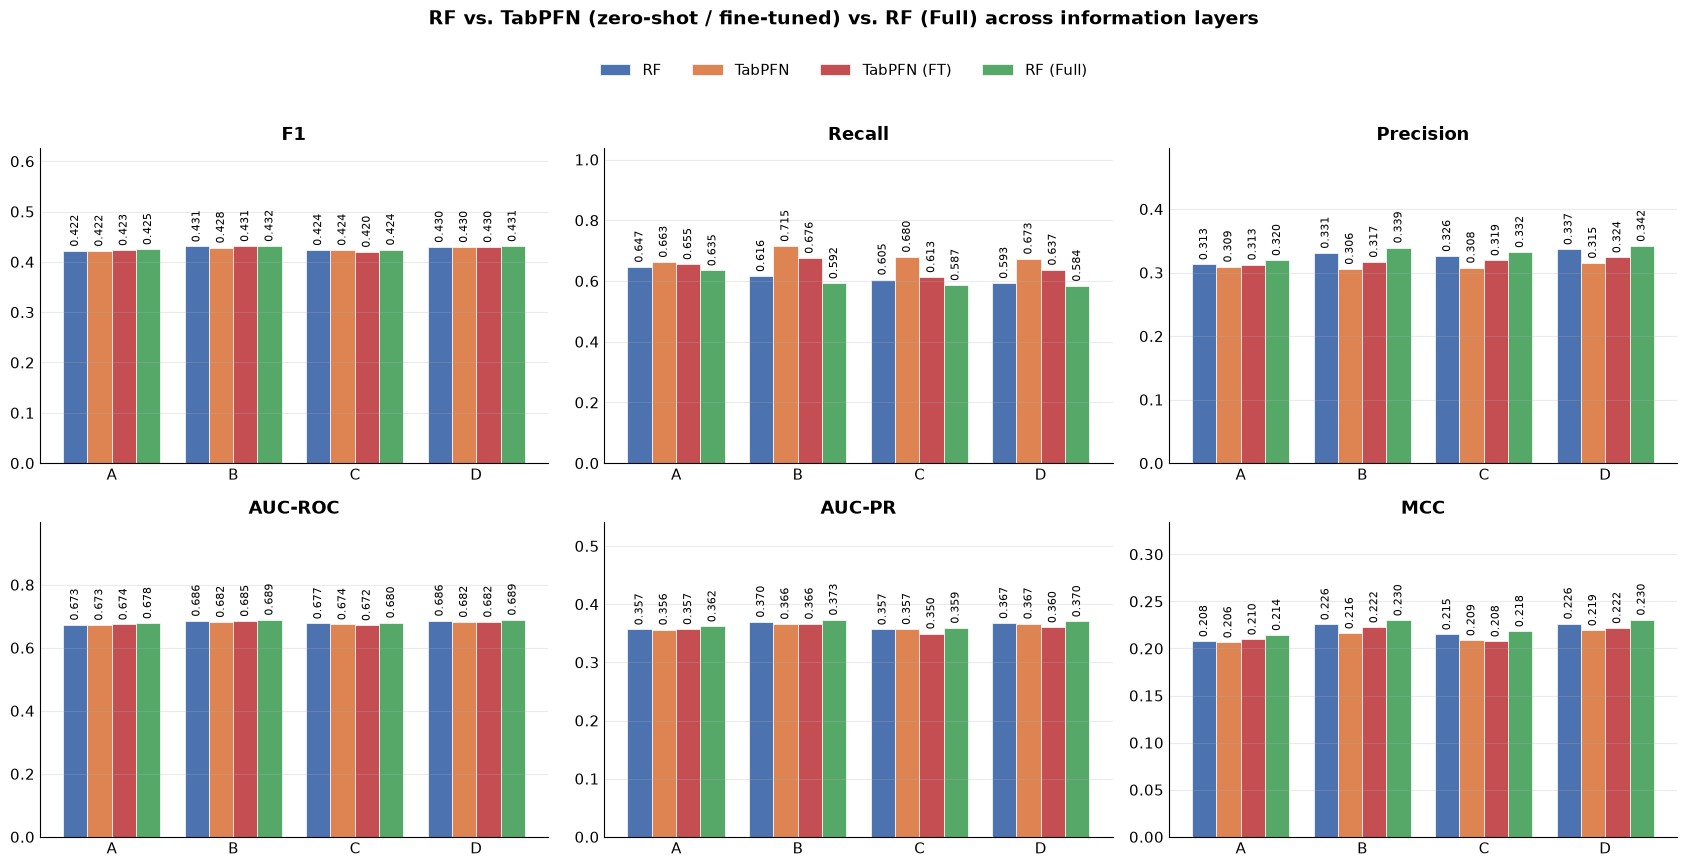

In [101]:
layers = layer_order
models = list(combined_df["model"].unique())
x = np.arange(len(layers))
bar_width = 0.8 / len(models)

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    for i, model in enumerate(models):
        subset = combined_df[combined_df["model"] == model].set_index("layer_label").loc[layers]
        offset = (i - (len(models) - 1) / 2) * bar_width
        bars = ax.bar(
            x + offset, subset[metric], width=bar_width,
            label=model, color=model_colors.get(model), edgecolor="white", linewidth=0.5,
        )
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels([l.split(":")[0] for l in layers])
    ax.set_title(metric_labels[metric], fontweight="bold")
    ax.set_ylim(0, max(combined_df[metric].max() * 1.45, 0.15))
    ax.tick_params(axis="both", length=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(models), bbox_to_anchor=(0.5, 1.03), frameon=False)
fig.suptitle("RF vs. TabPFN (zero-shot / fine-tuned) vs. RF (Full) across information layers", y=1.08, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(results_dir / "rf_vs_fm_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## 3b. Figure — average model performance across layers (bar chart)

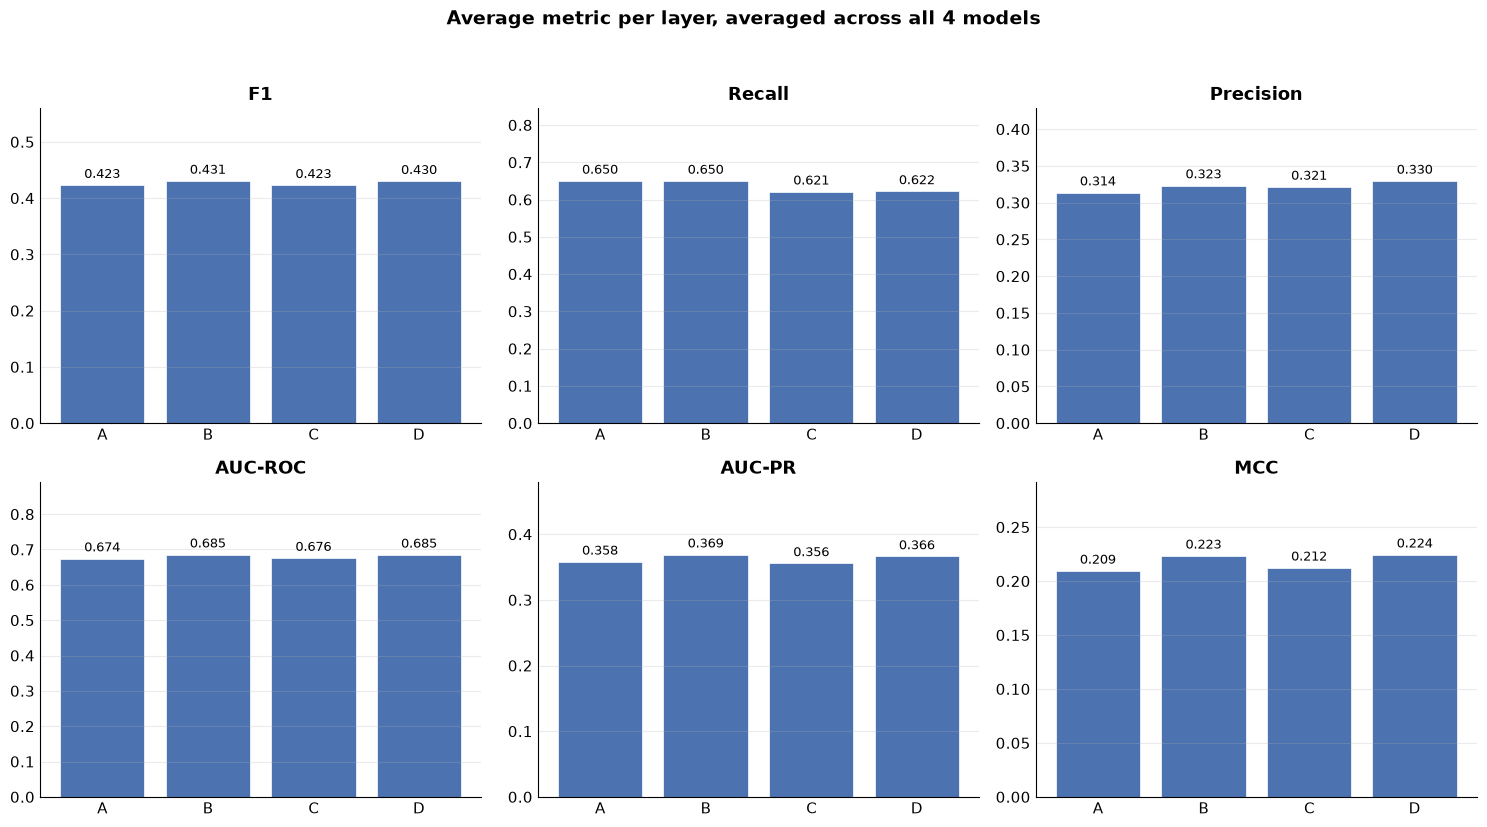

In [102]:
layer_avg_df = combined_df.groupby("layer_label")[metrics].mean().reindex(layer_order)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    bars = ax.bar(
        range(len(layer_order)), layer_avg_df[metric],
        color="#4C72B0", edgecolor="white", linewidth=0.5,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

    ax.set_xticks(range(len(layer_order)))
    ax.set_xticklabels([l.split(":")[0] for l in layer_order])
    ax.set_title(metric_labels[metric], fontweight="bold")
    ax.set_ylim(0, max(layer_avg_df[metric].max() * 1.3, 0.1))
    ax.tick_params(axis="both", length=0)

fig.suptitle(
    f"Average metric per layer, averaged across all {combined_df['model'].nunique()} models",
    y=1.03, fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.savefig(results_dir / "avg_metrics_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()

## 3c. Figure — average layer performance across models (bar chart)

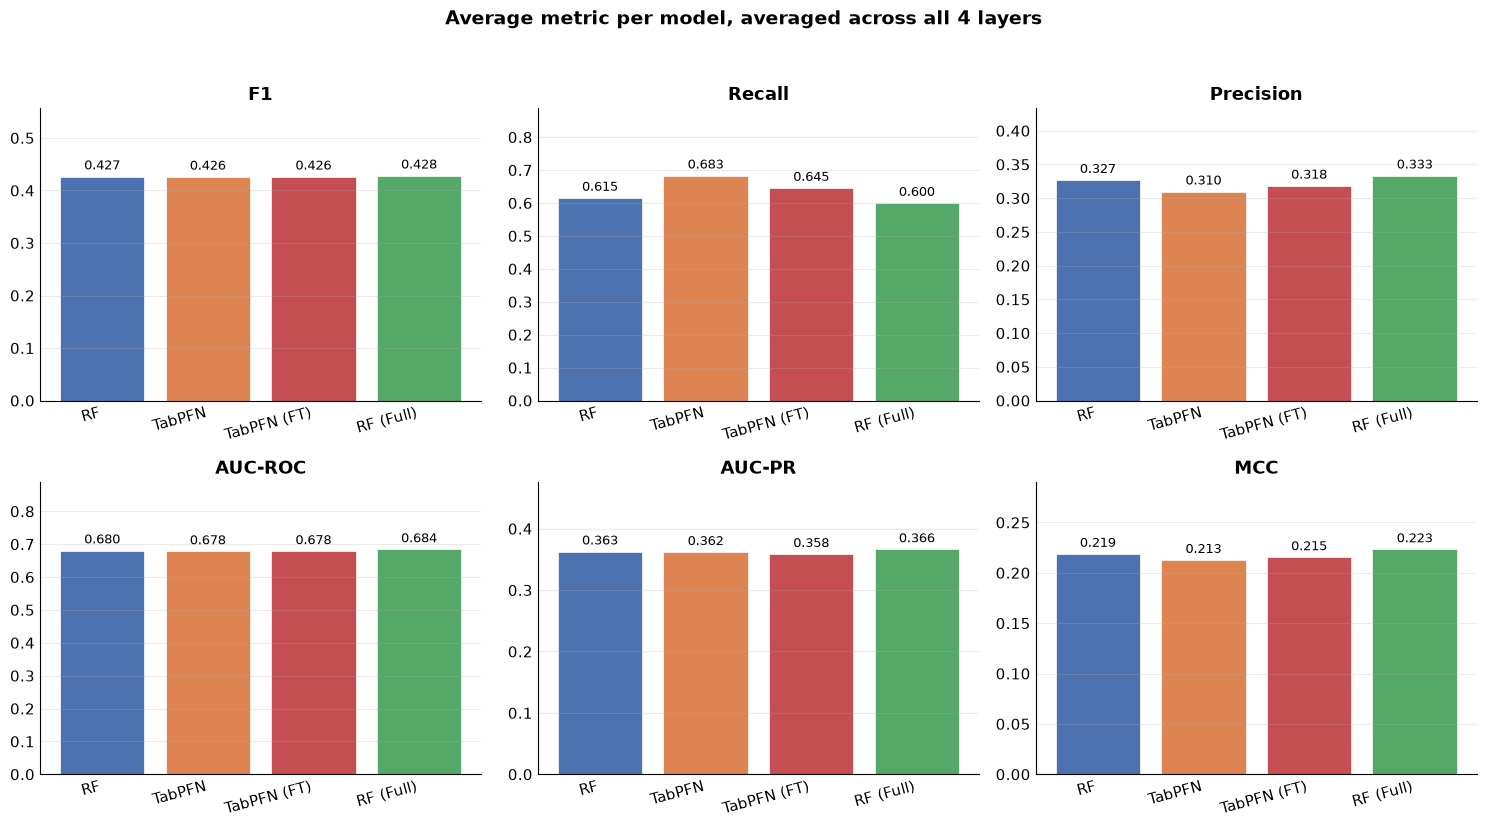

In [103]:
model_order = list(combined_df["model"].unique())
model_avg_df = combined_df.groupby("model")[metrics].mean().reindex(model_order)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    colors = [model_colors.get(m, "#999999") for m in model_order]
    bars = ax.bar(
        range(len(model_order)), model_avg_df[metric],
        color=colors, edgecolor="white", linewidth=0.5,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

    ax.set_xticks(range(len(model_order)))
    ax.set_xticklabels(model_order, rotation=15, ha="right")
    ax.set_title(metric_labels[metric], fontweight="bold")
    ax.set_ylim(0, max(model_avg_df[metric].max() * 1.3, 0.1))
    ax.tick_params(axis="both", length=0)

fig.suptitle(
    f"Average metric per model, averaged across all {len(layer_order)} layers",
    y=1.03, fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.savefig(results_dir / "avg_metrics_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. DeLong's test — setup

Every model is scored on the same 2025 test flights in every layer, so all comparisons are
paired on identical ground truth. Two families of tests, each Bonferroni-corrected on its own:
- **Model pairs**: all 6 pairs of the 4 models, within each layer (24 tests)
- **Layer pairs**: all 6 pairs of the 4 layers, within each model (24 tests)

In [104]:
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score

alpha = 0.05
min_meaningful_diff = 0.005  

model_order = ["RF", "RF (Full)", "TabPFN", "TabPFN (FT)"]
rf_full_template = "{name}_probs.npz"


def compute_midrank(x):
    """Average ranks for ties (1-based). Vectorised; same output as the old while-loop version."""
    return rankdata(x, method="average")


def fastDeLong(predictions_sorted_transposed, label_1_count):
    """Core DeLong covariance computation (Sun & Xu, 2014).
    predictions_sorted_transposed: (n_models, n_examples), positive-class examples first."""
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)
    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / (2.0 * n)
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.atleast_2d(np.cov(v01))
    sy = np.atleast_2d(np.cov(v10))
    delongcov = sx / m + sy / n
    return aucs, delongcov


def pairwise_delong(y_true, labels, proba_list):
    """Joint DeLong over k score vectors on the same y_true, then every pair (i, j) with i before j.
    auc_diff = auc_b - auc_a, i.e. the later item in `labels` minus the earlier one."""
    y_true = np.asarray(y_true)
    order = np.argsort(-y_true, kind="stable")  # positives first
    preds = np.vstack(proba_list)[:, order]
    aucs, cov = fastDeLong(preds, int(y_true.sum()))

    rows = []
    for i, j in combinations(range(len(labels)), 2):
        diff = aucs[j] - aucs[i]
        se = np.sqrt(cov[i, i] + cov[j, j] - 2 * cov[i, j])
        z = diff / se
        rows.append({
            "a": labels[i], "b": labels[j],
            "auc_a": aucs[i], "auc_b": aucs[j], "auc_diff": diff,
            "se": se, "z": z,
            "p_value": 2 * stats.norm.sf(abs(z)),  # sf avoids the 1 - cdf underflow to exactly 0
        })
    return rows


def add_effect_sizes_and_correction(df):
    """Adds relative gain, 95% and Bonferroni CIs, corrected p-values and a practical verdict.
    The family is the whole DataFrame passed in."""
    df = df.copy()
    k = len(df)
    z95 = stats.norm.ppf(1 - alpha / 2)
    z_bonf = stats.norm.ppf(1 - alpha / (2 * k))

    df["rel_gain"] = df["auc_diff"] / (df["auc_a"] - 0.5)  # share of skill above chance
    df["ci95_low"] = df["auc_diff"] - z95 * df["se"]
    df["ci95_high"] = df["auc_diff"] + z95 * df["se"]
    df["ci_bonf_low"] = df["auc_diff"] - z_bonf * df["se"]
    df["ci_bonf_high"] = df["auc_diff"] + z_bonf * df["se"]
    df["p_bonferroni"] = np.minimum(df["p_value"] * k, 1.0)
    df["sig_0.05"] = df["p_value"] < alpha
    df["sig_bonferroni"] = df["p_bonferroni"] < alpha

    t = min_meaningful_diff
    meaningful = (df["ci_bonf_low"] > t) | (df["ci_bonf_high"] < -t)
    negligible = (df["ci_bonf_low"] > -t) & (df["ci_bonf_high"] < t)
    df["verdict"] = np.select([meaningful, negligible], ["meaningful", "negligible"], "inconclusive")

    print(f"{df['family'].iloc[0]}: {k} tests | Bonferroni alpha = {alpha / k:.5f} | "
          f"CI z = {z_bonf:.3f} | threshold |ΔAUC| = {t}")
    return df

## 5. Load test-set probabilities for every model × layer

Fails loudly on a missing file instead of silently skipping a model.

In [105]:
def load_model_output(model, name):
    """Returns (y_test or None, proba). y_test only where the file stores it."""
    key = f"{name}_subsampled"
    if model == "RF":
        data = np.load(rf_dir / f"{key}_probs.npz")
        return data["y_test"], data["test_proba"]
    if model == "RF (Full)":
        data = np.load(rf_full_dir / rf_full_template.format(name=name))
        return data["y_test"], data["test_proba"]
    if model == "TabPFN":
        return None, np.load(tabpfn_dir / f"{key}_y_proba.npy")
    if model == "TabPFN (FT)":
        return None, np.load(tabpfn_tuned_dir / fm_tuned_proba_template.format(key=key))
    raise ValueError(model)


y_test = None
probs = {}  # (model, layer_label) -> 1-D probability array

for name in layer_files:
    layer = canonicalize_layer(name)
    for model in model_order:
        y_m, proba = load_model_output(model, name)
        proba = np.asarray(proba, dtype=float)
        assert proba.ndim == 1, f"{model} / {layer}: expected 1-D probabilities, got shape {proba.shape}"

        if y_test is None:
            y_test = np.asarray(y_m)  # first model loaded is RF, which stores y_test
        if y_m is not None:
            assert np.array_equal(y_m, y_test), (
                f"{model} / {layer}: y_test differs from the reference -- not the same test flights "
                f"(or not in the same order), so a paired test is invalid"
            )
        assert len(proba) == len(y_test), (
            f"{model} / {layer}: {len(proba)} probabilities vs {len(y_test)} test labels"
        )
        probs[(model, layer)] = proba

print(f"Loaded {len(probs)} model × layer probability sets on {len(y_test):,} test flights "
      f"({int(y_test.sum()):,} delayed, {y_test.mean():.1%})")

auc_table = pd.DataFrame(
    {m: [roc_auc_score(y_test, probs[(m, l)]) for l in layer_order] for m in model_order},
    index=layer_order,
)
auc_table.to_csv(results_dir / "auc_roc_by_model_layer.csv")
auc_table.round(4)

Loaded 16 model × layer probability sets on 5,966,559 test flights (1,303,658 delayed, 21.8%)


,RF,RF (Full),TabPFN,TabPFN (FT)
A: BTS,0.6731,0.6778,0.6728,0.6738
B: BTS+Weather,0.6856,0.6888,0.6820,0.6850
C: BTS+GDELT,0.6772,0.6800,0.6745,0.6715
D: BTS+Weather+GDELT,0.6860,0.6889,0.6821,0.6824


## 6. DeLong's test — all model pairs, within each layer

In [106]:
model_rows = []
for layer in layer_order:
    for r in pairwise_delong(y_test, model_order, [probs[(m, layer)] for m in model_order]):
        model_rows.append({"family": "model pairs", "group": layer, **r})

model_pair_df = add_effect_sizes_and_correction(pd.DataFrame(model_rows))
model_pair_df.to_csv(results_dir / "delong_model_pairs.csv", index=False)

show_cols = ["group", "a", "b", "auc_a", "auc_b", "auc_diff", "ci_bonf_low", "ci_bonf_high",
             "rel_gain", "p_value", "p_bonferroni", "sig_bonferroni", "verdict"]
model_pair_df[show_cols].round(4)

model pairs: 24 tests | Bonferroni alpha = 0.00208 | CI z = 3.078 | threshold |ΔAUC| = 0.005


,group,a,b,auc_a,auc_b,auc_diff,ci_bonf_low,ci_bonf_high,rel_gain,p_value,p_bonferroni,sig_bonferroni,verdict
0,A: BTS,RF,RF (Full),0.6731,0.6778,0.0047,0.0044,0.0050,0.0271,0.0000,0.0000,True,negligible
1,A: BTS,RF,TabPFN,0.6731,0.6728,-0.0004,-0.0007,-0.0000,-0.0022,0.0011,0.0261,True,negligible
2,A: BTS,RF,TabPFN (FT),0.6731,0.6738,0.0007,0.0003,0.0010,0.0039,0.0000,0.0000,True,negligible
3,A: BTS,RF (Full),TabPFN,0.6778,0.6728,-0.0051,-0.0054,-0.0047,-0.0285,0.0000,0.0000,True,inconclusive
4,A: BTS,RF (Full),TabPFN (FT),0.6778,0.6738,-0.0040,-0.0043,-0.0037,-0.0226,0.0000,0.0000,True,negligible
5,A: BTS,TabPFN,TabPFN (FT),0.6728,0.6738,0.0011,0.0008,0.0013,0.0062,0.0000,0.0000,True,negligible
6,B: BTS+Weather,RF,RF (Full),0.6856,0.6888,0.0033,0.0031,0.0035,0.0176,0.0000,0.0000,True,negligible
7,B: BTS+Weather,RF,TabPFN,0.6856,0.6820,-0.0036,-0.0039,-0.0033,-0.0193,0.0000,0.0000,True,negligible
8,B: BTS+Weather,RF,TabPFN (FT),0.6856,0.6850,-0.0006,-0.0009,-0.0003,-0.0031,0.0000,0.0000,True,negligible
9,B: BTS+Weather,RF (Full),TabPFN,0.6888,0.6820,-0.0069,-0.0072,-0.0066,-0.0363,0.0000,0.0000,True,meaningful


## 7. DeLong's test — all layer pairs, within each model

In [107]:
layer_rows = []
for model in model_order:
    for r in pairwise_delong(y_test, layer_order, [probs[(model, l)] for l in layer_order]):
        layer_rows.append({"family": "layer pairs", "group": model, **r})

layer_pair_df = add_effect_sizes_and_correction(pd.DataFrame(layer_rows))
layer_pair_df.to_csv(results_dir / "delong_layer_pairs.csv", index=False)
layer_pair_df[show_cols].round(4)

layer pairs: 24 tests | Bonferroni alpha = 0.00208 | CI z = 3.078 | threshold |ΔAUC| = 0.005


,group,a,b,auc_a,auc_b,auc_diff,ci_bonf_low,ci_bonf_high,rel_gain,p_value,p_bonferroni,sig_bonferroni,verdict
0,RF,A: BTS,B: BTS+Weather,0.6731,0.6856,0.0124,0.0121,0.0128,0.0718,0.0000,0.0000,True,meaningful
1,RF,A: BTS,C: BTS+GDELT,0.6731,0.6772,0.0040,0.0037,0.0043,0.0232,0.0000,0.0000,True,negligible
2,RF,A: BTS,D: BTS+Weather+GDELT,0.6731,0.6860,0.0129,0.0125,0.0132,0.0743,0.0000,0.0000,True,meaningful
3,RF,B: BTS+Weather,C: BTS+GDELT,0.6856,0.6772,-0.0084,-0.0087,-0.0081,-0.0453,0.0000,0.0000,True,meaningful
4,RF,B: BTS+Weather,D: BTS+Weather+GDELT,0.6856,0.6860,0.0004,0.0002,0.0007,0.0024,0.0000,0.0000,True,negligible
5,RF,C: BTS+GDELT,D: BTS+Weather+GDELT,0.6772,0.6860,0.0089,0.0086,0.0091,0.0500,0.0000,0.0000,True,meaningful
6,RF (Full),A: BTS,B: BTS+Weather,0.6778,0.6888,0.0110,0.0107,0.0113,0.0619,0.0000,0.0000,True,meaningful
7,RF (Full),A: BTS,C: BTS+GDELT,0.6778,0.6800,0.0021,0.0019,0.0024,0.0120,0.0000,0.0000,True,negligible
8,RF (Full),A: BTS,D: BTS+Weather+GDELT,0.6778,0.6889,0.0111,0.0107,0.0115,0.0624,0.0000,0.0000,True,meaningful
9,RF (Full),B: BTS+Weather,C: BTS+GDELT,0.6888,0.6800,-0.0089,-0.0092,-0.0085,-0.0470,0.0000,0.0000,True,meaningful


## 7b. Compact ΔAUC tables for the results chapters

Gain from each information layer over the BTS-only baseline (per model), and each model's
difference from the subsampled RF (per layer).

In [108]:
baseline = layer_order[0]
layer_gain = (
    layer_pair_df[layer_pair_df["a"] == baseline]
    .pivot(index="b", columns="group", values="auc_diff")
    .reindex(index=layer_order[1:], columns=model_order)
)
layer_gain.index = [f"{l} vs {baseline.split(':')[0]}" for l in layer_gain.index]
layer_gain.to_csv(results_dir / "delta_auc_vs_layer_a.csv")
print("ΔAUC-ROC vs. layer A (row layer − A):")
display(layer_gain.round(4))

model_gap = (
    model_pair_df[model_pair_df["a"] == "RF"]
    .pivot(index="group", columns="b", values="auc_diff")
    .reindex(index=layer_order, columns=model_order[1:])
)
model_gap.columns = [f"{m} − RF" for m in model_gap.columns]
model_gap.to_csv(results_dir / "delta_auc_vs_rf.csv")
print("ΔAUC-ROC vs. RF (subsampled):")
display(model_gap.round(4))

ΔAUC-ROC vs. layer A (row layer − A):


group,RF,RF (Full),TabPFN,TabPFN (FT)
B: BTS+Weather vs A,0.0124,0.0110,0.0092,0.0112
C: BTS+GDELT vs A,0.0040,0.0021,0.0017,-0.0023
D: BTS+Weather+GDELT vs A,0.0129,0.0111,0.0094,0.0086


ΔAUC-ROC vs. RF (subsampled):


,RF (Full) − RF,TabPFN − RF,TabPFN (FT) − RF
group,,,
A: BTS,0.0047,-0.0004,0.0007
B: BTS+Weather,0.0033,-0.0036,-0.0006
C: BTS+GDELT,0.0028,-0.0027,-0.0056
D: BTS+Weather+GDELT,0.0029,-0.0039,-0.0036


## 8. Figures — pairwise AUC-ROC differences

Cell = row − column. `**` = Bonferroni-significant, `*` = significant only at uncorrected 0.05.
One colour scale per figure so panels are comparable.

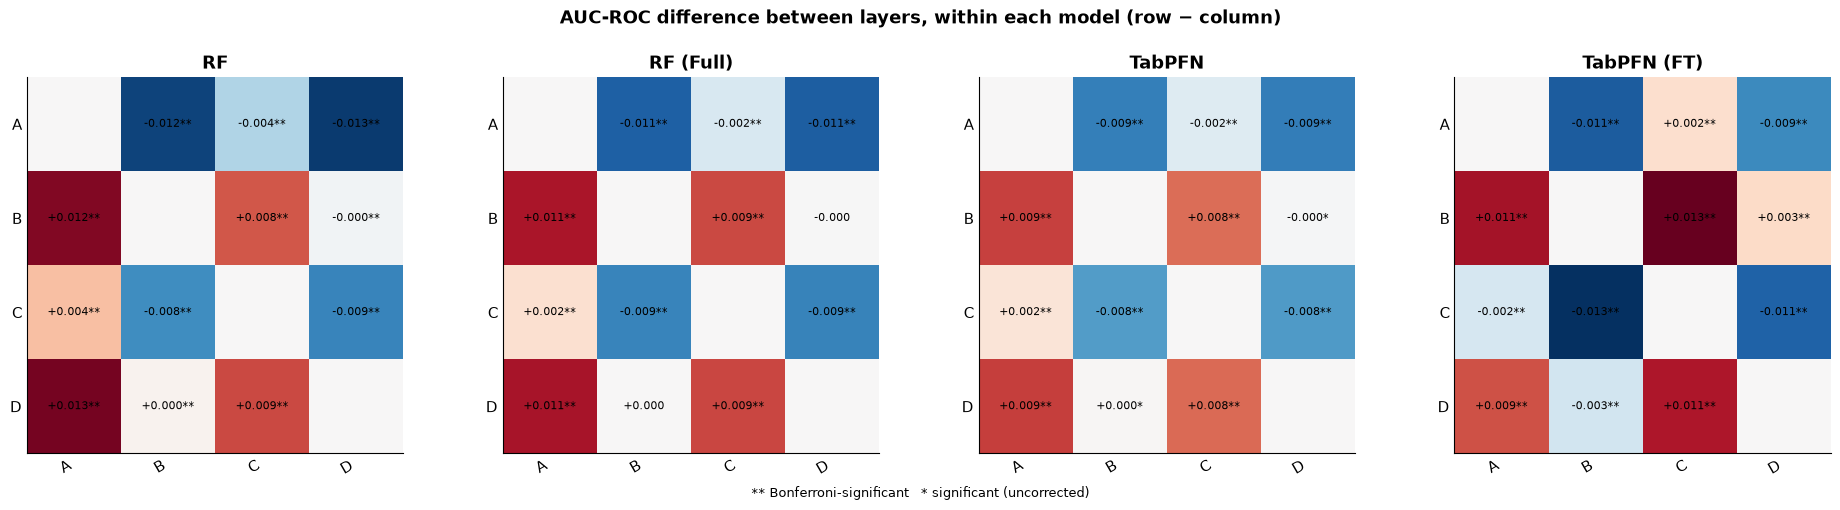

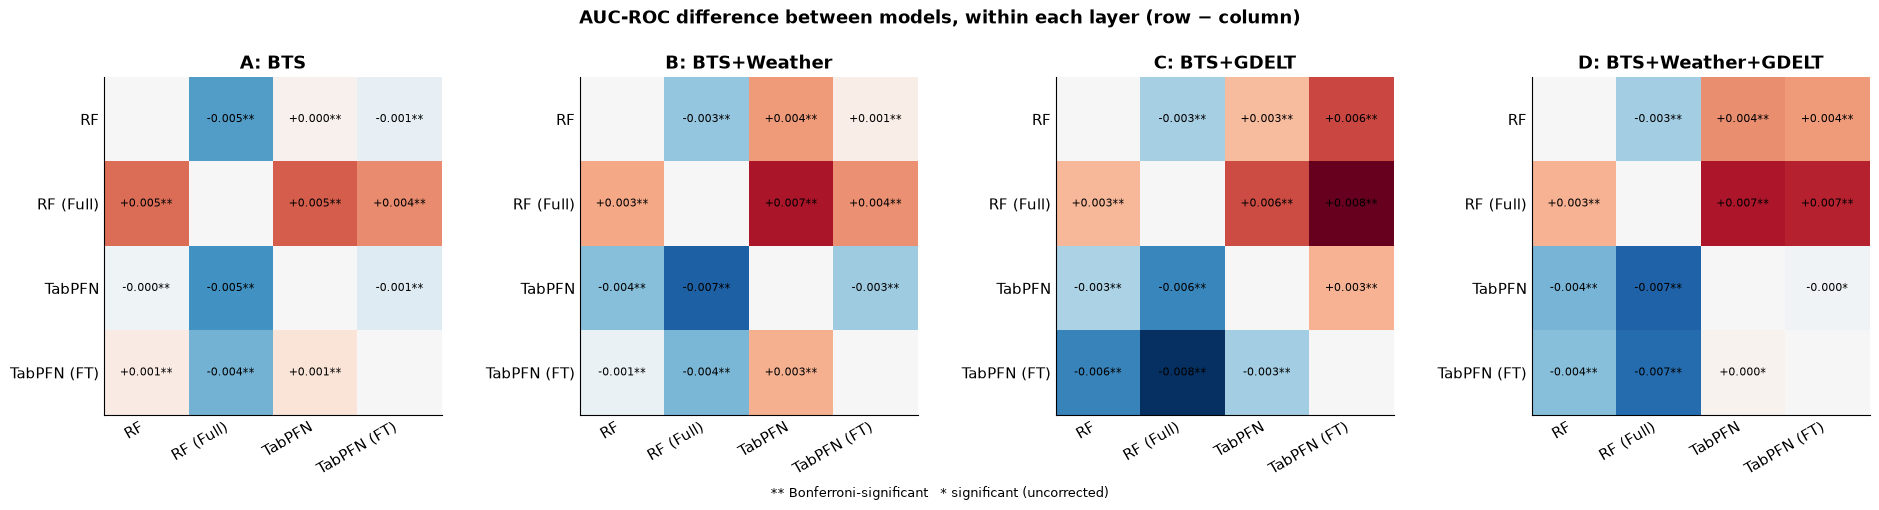

In [109]:
def plot_diff_heatmaps(df, order, title, fname):
    groups = list(dict.fromkeys(df["group"]))
    vmax = df["auc_diff"].abs().max()
    short = lambda s: s.split(":")[0]

    fig, axes = plt.subplots(1, len(groups), figsize=(4.8 * len(groups), 4.6))
    for ax, g in zip(np.atleast_1d(axes), groups):
        mat = pd.DataFrame(0.0, index=order, columns=order)
        star = pd.DataFrame("", index=order, columns=order)
        for _, r in df[df["group"] == g].iterrows():
            mat.loc[r["b"], r["a"]] = r["auc_diff"]
            mat.loc[r["a"], r["b"]] = -r["auc_diff"]
            mark = "**" if r["sig_bonferroni"] else ("*" if r["sig_0.05"] else "")
            star.loc[r["b"], r["a"]] = mark
            star.loc[r["a"], r["b"]] = mark

        ax.imshow(mat.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        for i in range(len(order)):
            for j in range(len(order)):
                if i != j:
                    ax.text(j, i, f"{mat.values[i, j]:+.3f}{star.values[i, j]}",
                            ha="center", va="center", fontsize=8)
        ax.set_xticks(range(len(order)))
        ax.set_yticks(range(len(order)))
        ax.set_xticklabels([short(o) for o in order], rotation=30, ha="right")
        ax.set_yticklabels([short(o) for o in order])
        ax.set_title(g, fontweight="bold")
        ax.tick_params(axis="both", length=0)
        ax.grid(False)

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    fig.text(0.5, -0.04, "** Bonferroni-significant   * significant (uncorrected)", ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig(results_dir / fname, dpi=150, bbox_inches="tight")
    plt.show()


plot_diff_heatmaps(layer_pair_df, layer_order,
                   "AUC-ROC difference between layers, within each model (row − column)",
                   "delong_layer_pairs_heatmap.png")
plot_diff_heatmaps(model_pair_df, model_order,
                   "AUC-ROC difference between models, within each layer (row − column)",
                   "delong_model_pairs_heatmap.png")

## 9. Robustness check — excluding Honolulu (HNL)

The Meteostat station assigned to HNL only reports from July 2025, so HNL's weather features are
median-imputed throughout training and the first half of the holdout. HNL is ~1% of departures.

This section re-evaluates every model on the same test flights **without HNL** — no retraining,
only the predictions are filtered. It checks whether

- the layer gains (ΔAUC-ROC vs. layer A) change,
- the DeLong conclusions for layer pairs (Bonferroni significance, verdict) change,
- threshold metrics (F1, MCC) change, using the thresholds already tuned (not re-tuned).

**Finding HNL without the airport code.** The final files only hold the target-encoded origin.
Because the encoding is fit on 2024 and mapped onto 2025, every test flight from the same airport
carries the same encoded value. HNL is the one encoded value whose test flights have the imputed
weather value in about half of all 2025 rows (January–June); for every other airport that share is
close to zero. The imputed value is found as the most frequent value of the temperature lookback
column, since a real trailing mean almost never repeats exactly.

In [110]:
# --- Identify HNL's test flights via its weather-imputation signature ----------------------
import pyarrow.parquet as pq

target_col = "dep_del15"
test_year = 2025
excluded_airport = "HNL"

# Layer B holds the weather columns; test rows are identical across layers (asserted in section 5).
layer_b_path = final_data_path / f"{layer_files[1]}_features.parquet"   # same file the modeling notebooks loaded
if not layer_b_path.exists():
    raise FileNotFoundError(
        f"{layer_b_path} not found. Parquet files in {final_data_path}:\n"
        + "\n".join(f"  {f.name}" for f in sorted(final_data_path.glob("*.parquet")))
    )
schema_cols = pq.read_schema(layer_b_path).names

def pick(candidates, what):
    found = [c for c in candidates if c in schema_cols]
    if not found:
        raise KeyError(f"No {what} column found -- set it by hand. Columns in file:\n{schema_cols}")
    return found[0]

# Set any of these by hand if the auto-detection picks the wrong column.
origin_candidates = [c for c in schema_cols if "origin" in c.lower()]
origin_col = pick(origin_candidates, "encoded origin")
temp_candidates = [c for c in schema_cols if "temp" in c.lower()]
temp_col = pick(sorted(temp_candidates, key=lambda c: ("12" not in c, c)), "temperature lookback")
date_col = pick(["FL_DATE", "fl_date", "flight_date", "date", "YEAR", "year"], "date/year")
print(f"{layer_b_path.name}: origin = '{origin_col}', temperature = '{temp_col}', split on '{date_col}'")
if len(origin_candidates) > 1:
    print(f"  note: several origin columns found {origin_candidates} -- check that '{origin_col}' is the encoded one")

df = pd.read_parquet(layer_b_path, columns=[origin_col, temp_col, date_col, target_col])

# Repeat the time split. If the modeling notebook split differently (other column, other
# cut-off, dropped rows first), copy that exact line here -- the assertions below will tell you.
if date_col.lower() == "year":
    is_test = df[date_col] == test_year
else:
    is_test = pd.to_datetime(df[date_col]).dt.year == test_year
test_rows = df[is_test].reset_index(drop=True)
del df

assert len(test_rows) == len(y_test), (
    f"{len(test_rows):,} test rows after the split vs {len(y_test):,} saved test labels -- "
    f"the split here differs from the modeling notebook"
)
assert np.array_equal(test_rows[target_col].to_numpy(), y_test), (
    "Labels differ from y_test -- rows are not in the same order as the saved predictions"
)

# Imputed rows = NaN (if imputation happens at modeling time) or the most frequent exact value
if test_rows[temp_col].isna().any():
    is_imputed = test_rows[temp_col].isna()
    print("Temperature column contains NaN -- using missingness as the signature")
else:
    imputed_value = test_rows[temp_col].mode().iloc[0]
    is_imputed = test_rows[temp_col] == imputed_value
    print(f"Imputed temperature value: {imputed_value:.4f}")

signature = (
    test_rows.assign(imputed=is_imputed)
    .groupby(origin_col)
    .agg(n_test_flights=(target_col, "size"), imputed_share=("imputed", "mean"))
    .sort_values("imputed_share", ascending=False)
)
print(f"Encoded origin values in test: {len(signature)}")
display(signature.head(5).round(4))

hnl_code = signature.index[0]
assert signature["imputed_share"].iloc[0] > 0.30, "No airport with a clear imputation signature"
assert signature["imputed_share"].iloc[1] < 0.10, "Second airport also looks imputed -- check by hand"
print(f"{excluded_airport} = encoded origin {hnl_code} (should be close to HNL's 2024 delay rate, ~0.136)")

is_hnl = (test_rows[origin_col] == hnl_code).to_numpy()
if date_col.lower() != "year":
    hnl_months = pd.to_datetime(test_rows.loc[is_hnl, date_col]).dt.month.to_numpy()
    print("Imputed share by month for this airport (expect ~1 for Jan-Jun, ~0 for Jul-Dec):")
    display(is_imputed[is_hnl].groupby(hnl_months).mean().round(3).to_frame("imputed_share").T)

keep_mask = ~is_hnl
hnl_mask = is_hnl
print(f"{excluded_airport}: {hnl_mask.sum():,} test flights ({hnl_mask.mean():.2%}), "
      f"delay rate {y_test[hnl_mask].mean():.1%} vs {y_test[keep_mask].mean():.1%} elsewhere")
print(f"Remaining: {keep_mask.sum():,} test flights")

layer_b_bts_meteostat_features.parquet: origin = 'origin_te', temperature = 'temp_mean_12h', split on 'year'
Imputed temperature value: 17.6833
Encoded origin values in test: 114


,n_test_flights,imputed_share
origin_te,,
0.135679,57709,0.5658
0.249406,7183,0.0209
0.236686,51293,0.0175
0.196742,13515,0.0165
0.167033,12505,0.0162


HNL = encoded origin 0.13567883286778695 (should be close to HNL's 2024 delay rate, ~0.136)
HNL: 57,709 test flights (0.97%), delay rate 12.6% vs 21.9% elsewhere
Remaining: 5,908,850 test flights


In [111]:
# --- AUC-ROC / AUC-PR with and without HNL -------------------------------------------------
from sklearn.metrics import average_precision_score

y_excl = y_test[keep_mask]
auc_rows = []
for model in model_order:
    for layer in layer_order:
        p = probs[(model, layer)]
        auc_rows.append({
            "model": model, "layer": layer,
            "auc_roc_all": roc_auc_score(y_test, p),
            "auc_roc_excl": roc_auc_score(y_excl, p[keep_mask]),
            "auc_pr_all": average_precision_score(y_test, p),
            "auc_pr_excl": average_precision_score(y_excl, p[keep_mask]),
        })
hnl_auc_df = pd.DataFrame(auc_rows)
hnl_auc_df["auc_roc_change"] = hnl_auc_df["auc_roc_excl"] - hnl_auc_df["auc_roc_all"]
hnl_auc_df["auc_pr_change"] = hnl_auc_df["auc_pr_excl"] - hnl_auc_df["auc_pr_all"]
hnl_auc_df.to_csv(results_dir / "robustness_excl_hnl_auc.csv", index=False)
hnl_auc_df.round(4)

,model,layer,auc_roc_all,auc_roc_excl,auc_pr_all,auc_pr_excl,auc_roc_change,auc_pr_change
0,RF,A: BTS,0.6731,0.6728,0.3565,0.3572,-0.0003,0.0007
1,RF,B: BTS+Weather,0.6856,0.6854,0.3697,0.3705,-0.0002,0.0008
2,RF,C: BTS+GDELT,0.6772,0.6768,0.3565,0.3572,-0.0004,0.0007
3,RF,D: BTS+Weather+GDELT,0.6860,0.6858,0.3675,0.3682,-0.0003,0.0007
4,RF (Full),A: BTS,0.6778,0.6775,0.3618,0.3626,-0.0003,0.0007
5,RF (Full),B: BTS+Weather,0.6888,0.6887,0.3732,0.3741,-0.0002,0.0009
6,RF (Full),C: BTS+GDELT,0.6800,0.6796,0.3593,0.3600,-0.0004,0.0007
7,RF (Full),D: BTS+Weather+GDELT,0.6889,0.6887,0.3703,0.3710,-0.0003,0.0007
8,TabPFN,A: BTS,0.6728,0.6725,0.3564,0.3571,-0.0003,0.0007
9,TabPFN,B: BTS+Weather,0.6820,0.6818,0.3663,0.3670,-0.0002,0.0007


In [112]:
# --- DeLong layer pairs without HNL, compared with the main results ------------------------
layer_rows_excl = []
for model in model_order:
    for r in pairwise_delong(y_excl, layer_order, [probs[(model, l)][keep_mask] for l in layer_order]):
        layer_rows_excl.append({"family": "layer pairs (excl. HNL)", "group": model, **r})

layer_pair_excl_df = add_effect_sizes_and_correction(pd.DataFrame(layer_rows_excl))
layer_pair_excl_df.to_csv(results_dir / "delong_layer_pairs_excl_hnl.csv", index=False)

key_cols = ["group", "a", "b"]
compare_cols = ["auc_diff", "p_bonferroni", "sig_bonferroni", "verdict"]
layer_compare = layer_pair_df[key_cols + compare_cols].merge(
    layer_pair_excl_df[key_cols + compare_cols], on=key_cols, suffixes=("_all", "_excl")
)
layer_compare["diff_change"] = layer_compare["auc_diff_excl"] - layer_compare["auc_diff_all"]
layer_compare["sig_changed"] = layer_compare["sig_bonferroni_all"] != layer_compare["sig_bonferroni_excl"]
layer_compare["verdict_changed"] = layer_compare["verdict_all"] != layer_compare["verdict_excl"]
layer_compare.to_csv(results_dir / "robustness_excl_hnl_delong_comparison.csv", index=False)

print(f"Largest change in a layer ΔAUC-ROC: {layer_compare['diff_change'].abs().max():.5f}")
print(f"Significance flips (Bonferroni): {layer_compare['sig_changed'].sum()} / {len(layer_compare)}")
print(f"Verdict changes: {layer_compare['verdict_changed'].sum()} / {len(layer_compare)}")
if layer_compare[["sig_changed", "verdict_changed"]].any(axis=None):
    display(layer_compare[layer_compare["sig_changed"] | layer_compare["verdict_changed"]].round(4))
layer_compare.round(4)

layer pairs (excl. HNL): 24 tests | Bonferroni alpha = 0.00208 | CI z = 3.078 | threshold |ΔAUC| = 0.005
Largest change in a layer ΔAUC-ROC: 0.00021
Significance flips (Bonferroni): 1 / 24
Verdict changes: 0 / 24


,group,a,b,auc_diff_all,p_bonferroni_all,sig_bonferroni_all,verdict_all,auc_diff_excl,p_bonferroni_excl,sig_bonferroni_excl,verdict_excl,diff_change,sig_changed,verdict_changed
16,TabPFN,B: BTS+Weather,D: BTS+Weather+GDELT,0.0001,0.1916,False,negligible,0.0002,0.0493,True,negligible,0.0,True,False


,group,a,b,auc_diff_all,p_bonferroni_all,sig_bonferroni_all,verdict_all,auc_diff_excl,p_bonferroni_excl,sig_bonferroni_excl,verdict_excl,diff_change,sig_changed,verdict_changed
0,RF,A: BTS,B: BTS+Weather,0.0124,0.0000,True,meaningful,0.0125,0.0000,True,meaningful,0.0001,False,False
1,RF,A: BTS,C: BTS+GDELT,0.0040,0.0000,True,negligible,0.0040,0.0000,True,negligible,-0.0000,False,False
2,RF,A: BTS,D: BTS+Weather+GDELT,0.0129,0.0000,True,meaningful,0.0129,0.0000,True,meaningful,0.0001,False,False
3,RF,B: BTS+Weather,C: BTS+GDELT,-0.0084,0.0000,True,meaningful,-0.0086,0.0000,True,meaningful,-0.0002,False,False
4,RF,B: BTS+Weather,D: BTS+Weather+GDELT,0.0004,0.0000,True,negligible,0.0004,0.0000,True,negligible,-0.0001,False,False
5,RF,C: BTS+GDELT,D: BTS+Weather+GDELT,0.0089,0.0000,True,meaningful,0.0089,0.0000,True,meaningful,0.0001,False,False
6,RF (Full),A: BTS,B: BTS+Weather,0.0110,0.0000,True,meaningful,0.0112,0.0000,True,meaningful,0.0002,False,False
7,RF (Full),A: BTS,C: BTS+GDELT,0.0021,0.0000,True,negligible,0.0021,0.0000,True,negligible,-0.0001,False,False
8,RF (Full),A: BTS,D: BTS+Weather+GDELT,0.0111,0.0000,True,meaningful,0.0112,0.0000,True,meaningful,0.0001,False,False
9,RF (Full),B: BTS+Weather,C: BTS+GDELT,-0.0089,0.0000,True,meaningful,-0.0091,0.0000,True,meaningful,-0.0002,False,False


In [113]:
# --- Compact table: ΔAUC-ROC vs. layer A, with and without HNL -----------------------------
def gain_table(df):
    t = (df[df["a"] == baseline]
         .pivot(index="b", columns="group", values="auc_diff")
         .reindex(index=layer_order[1:], columns=model_order))
    t.index = [f"{l.split(':')[0]} vs A" for l in t.index]
    return t

gain_compare = pd.concat(
    {"All test flights": gain_table(layer_pair_df), f"Excl. {excluded_airport}": gain_table(layer_pair_excl_df)},
    axis=1,
)
gain_compare.to_csv(results_dir / "robustness_excl_hnl_layer_gain.csv")
gain_compare.round(4)

All test flights                               Excl. HNL            \
group                RF RF (Full)  TabPFN TabPFN (FT)        RF RF (Full)   
B vs A           0.0124    0.0110  0.0092      0.0112    0.0125    0.0112   
C vs A           0.0040    0.0021  0.0017     -0.0023    0.0040    0.0021   
D vs A           0.0129    0.0111  0.0094      0.0086    0.0129    0.0112   

                            
group   TabPFN TabPFN (FT)  
B vs A  0.0093      0.0112  
C vs A  0.0017     -0.0024  
D vs A  0.0095      0.0086

In [114]:
# --- F1 / MCC at the already-tuned thresholds (only if the summaries store them) ----------
from sklearn.metrics import f1_score, matthews_corrcoef

def find_threshold_col(df):
    cols = [c for c in df.columns if "thresh" in c.lower()]
    return cols[0] if cols else None

threshold_rows = []
for model, df in sources.items():
    col = find_threshold_col(df)
    if col is None:
        print(f"{model}: no threshold column in its summary CSV -- F1/MCC skipped")
        continue
    for _, row in df.iterrows():
        layer, thr = row["layer_label"], float(row[col])
        pred = (probs[(model, layer)] >= thr).astype(int)
        threshold_rows.append({
            "model": model, "layer": layer, "threshold": thr,
            "f1_all": f1_score(y_test, pred), "f1_excl": f1_score(y_excl, pred[keep_mask]),
            "mcc_all": matthews_corrcoef(y_test, pred), "mcc_excl": matthews_corrcoef(y_excl, pred[keep_mask]),
        })

if threshold_rows:
    hnl_thr_df = pd.DataFrame(threshold_rows)
    hnl_thr_df["f1_change"] = hnl_thr_df["f1_excl"] - hnl_thr_df["f1_all"]
    hnl_thr_df["mcc_change"] = hnl_thr_df["mcc_excl"] - hnl_thr_df["mcc_all"]
    # sanity check: f1_all should reproduce the summary tables
    hnl_thr_df.to_csv(results_dir / "robustness_excl_hnl_threshold_metrics.csv", index=False)
    display(hnl_thr_df.round(4))

,model,layer,threshold,f1_all,f1_excl,mcc_all,mcc_excl,f1_change,mcc_change
0,RF,A: BTS,0.4464,0.4219,0.4228,0.2076,0.2075,0.0008,-0.0002
1,RF,B: BTS+Weather,0.4538,0.4307,0.4317,0.2255,0.2256,0.0009,0.0000
2,RF,C: BTS+GDELT,0.4531,0.4237,0.4245,0.2149,0.2147,0.0008,-0.0002
3,RF,D: BTS+Weather+GDELT,0.4549,0.4297,0.4305,0.2264,0.2263,0.0009,-0.0001
4,TabPFN,A: BTS,0.1920,0.4219,0.4227,0.2063,0.2061,0.0009,-0.0002
5,TabPFN,B: BTS+Weather,0.1761,0.4284,0.4293,0.2160,0.2160,0.0009,-0.0000
6,TabPFN,C: BTS+GDELT,0.1920,0.4237,0.4246,0.2087,0.2086,0.0009,-0.0001
7,TabPFN,D: BTS+Weather+GDELT,0.1891,0.4295,0.4305,0.2192,0.2192,0.0009,0.0000
8,TabPFN (FT),A: BTS,0.1844,0.4234,0.4244,0.2095,0.2096,0.0010,0.0001
9,TabPFN (FT),B: BTS+Weather,0.1835,0.4314,0.4324,0.2224,0.2225,0.0010,0.0001


In [115]:
# --- Context: HNL flights only, layer A vs. B ----------------------------------------------
# Expectation: little or no weather gain at HNL, since its weather is imputed in training.
y_hnl = y_test[hnl_mask]
hnl_only = pd.DataFrame(
    {m: [roc_auc_score(y_hnl, probs[(m, l)][hnl_mask]) for l in layer_order] for m in model_order},
    index=layer_order,
)
print(f"AUC-ROC on {hnl_mask.sum():,} HNL test flights only:")
hnl_only.round(4)

AUC-ROC on 57,709 HNL test flights only:


,RF,RF (Full),TabPFN,TabPFN (FT)
A: BTS,0.6314,0.6433,0.6162,0.6321
B: BTS+Weather,0.6333,0.6404,0.6251,0.6330
C: BTS+GDELT,0.6398,0.6457,0.6109,0.6370
D: BTS+Weather+GDELT,0.6439,0.6476,0.6277,0.6308


In [116]:
# --- LaTeX table for the appendix ----------------------------------------------------------
# rows = models, columns = (All / Excl. HNL) x (B, C, D vs A)
latex_gain = pd.concat(
    {"All test flights": gain_table(layer_pair_df).T, f"Excl. {excluded_airport}": gain_table(layer_pair_excl_df).T},
    axis=1,
)
latex_gain.to_latex(
    results_dir / "robustness_excl_hnl_layer_gain.tex",
    float_format="%.4f",
    caption=(f"Robustness check: $\\Delta$AUC-ROC of each information layer over layer A, "
             f"on all test flights and excluding {excluded_airport}. No models were retrained."),
    label="tab:robustness_excl_hnl",
    position="htbp",
    multicolumn_format="c",
)
print("Saved", results_dir / "robustness_excl_hnl_layer_gain.tex")

Saved /Users/aniaandruszkiewicz/FS/Thesis/data/final/modeling_results/robustness_excl_hnl_layer_gain.tex
